# OpenCV-based Methods

In [1]:
import cv2

import skimage

from pathlib import Path
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

from utils import remove_junction, segment_hair_fragments

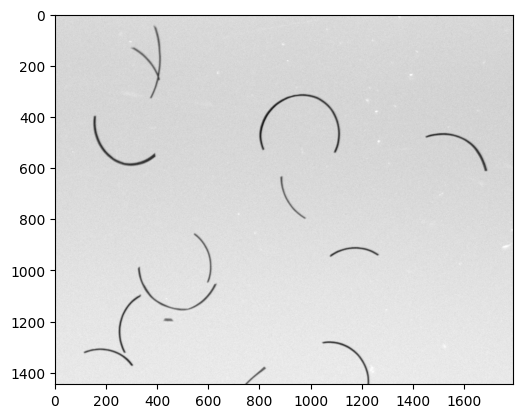

In [2]:
resolution = 132
min_size = int(0.5 * resolution)

# read a grayscale image
input_path = Path("data/curv/004_demo_curv.tiff")
img = Image.open(input_path)
# convert to numpy array
gray_img = np.array(img.convert("L"))
# resize the image
height, width = 1446, 1794
gray_img = cv2.resize(gray_img, (width, height))

plt.imshow(gray_img, cmap="gray")

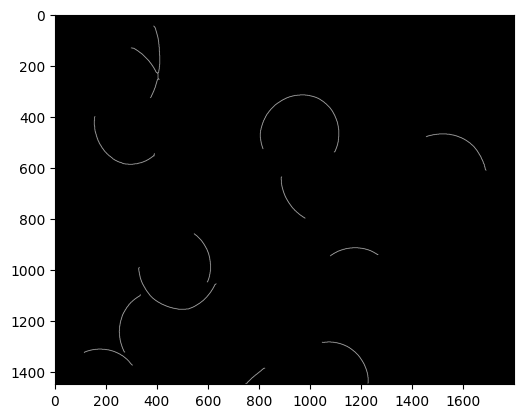

In [3]:
skeleton = segment_hair_fragments(gray_img, min_size=min_size)
dilated = skimage.morphology.dilation(skeleton, np.ones((2, 2)))
plt.imshow(dilated, cmap="gray")

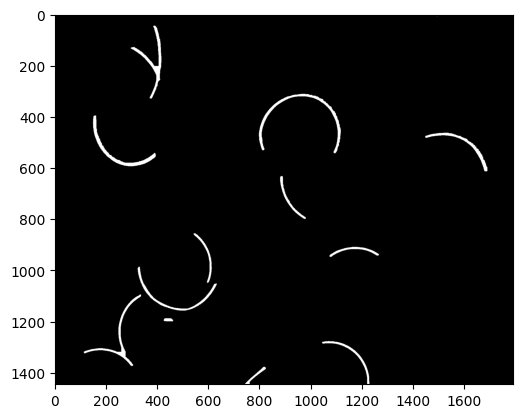

In [4]:
# edge-based detection

# pre-filter dark regions
# create a mask for dark pixels
# threshold values can be tuned depending on your image
_, dark_mask = cv2.threshold(gray_img, 200, 255, cv2.THRESH_BINARY_INV)

# apply mask to focus on dark areas only
masked_gray = np.where(dark_mask, gray_img, 255)

# apply Gaussian blur to reduce noise and improve edge detection
blurred = cv2.GaussianBlur(masked_gray, (5, 5), 0)

# apply Canny edge detection
edges = cv2.Canny(blurred, 50, 200)

# Dilate to connect fragmented edges
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=4)

# skeletonize the image
skeleton = skimage.morphology.skeletonize(closed)
skeleton = skimage.morphology.remove_small_objects(skeleton, min_size=min_size, connectivity=2)

plt.imshow(closed, cmap="gray")

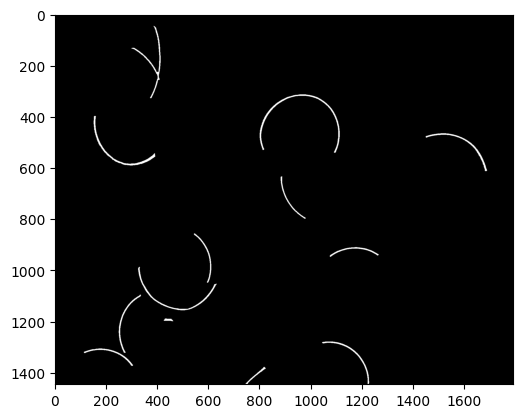

In [5]:
# adaptive thresholding
# apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)
# apply adaptive thresholding
adaptive_thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 9
)

# Dilate to connect fragmented edges
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
closed = cv2.morphologyEx(adaptive_thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

# skeletonize the image
skeleton = skimage.morphology.skeletonize(closed)
skeleton = skimage.morphology.remove_small_objects(skeleton, min_size=min_size, connectivity=2)

plt.imshow(closed, cmap="gray")

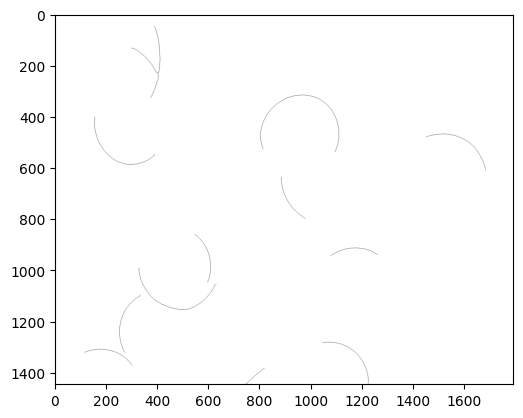

In [6]:
plt.imshow(skimage.util.invert(skeleton), cmap="gray")

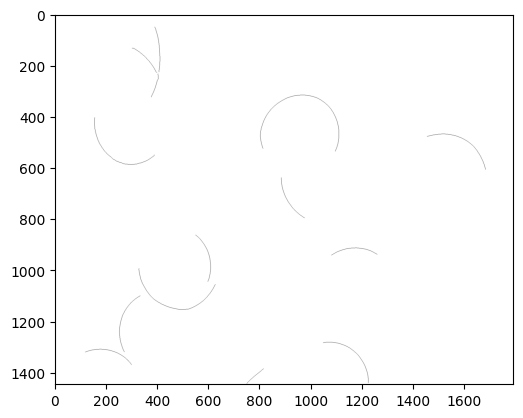

In [7]:
removed_img = remove_junction(skeleton)
plt.imshow(skimage.util.invert(removed_img), cmap="gray")

In [8]:
labels, num_labels = skimage.measure.label(skeleton, connectivity=2, return_num=True)
num_labels

12

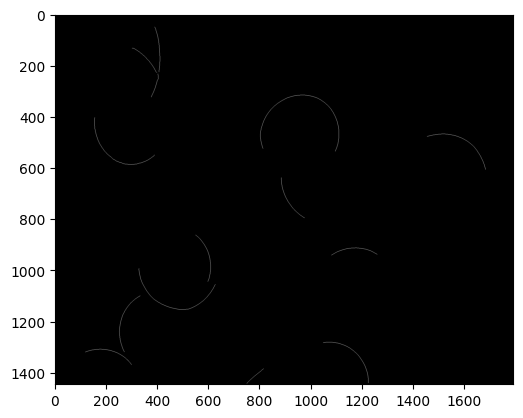

In [9]:
prune = remove_junction(skeleton)
plt.imshow(prune, cmap="gray")

In [10]:
from utils import calculate_curvature

In [11]:
curvatures, summary = calculate_curvature(prune)

In [14]:
summary["mean_curvature"]

0.8085500043387194

In [17]:
f'Mean = {summary["mean_curvature"]:.2f}'

'Mean = 0.81'

/var/folders/_v/m25cfnf53bl_k0s55_2bkc280000gn/T/ipykernel_78820/111776378.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


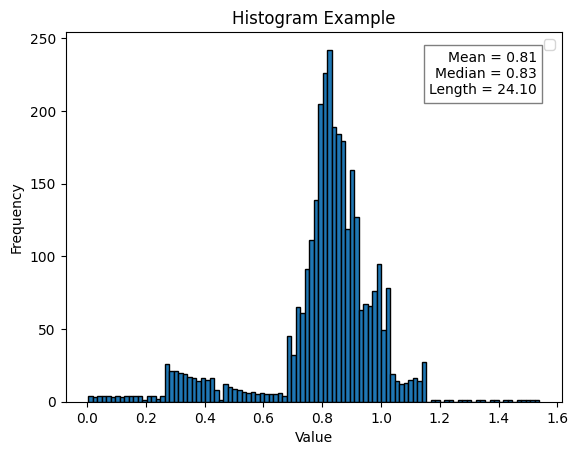

In [ ]:
plt.hist(curvatures, bins=100, edgecolor='black')
# Add text box with statistics
stats_text = f'Mean = {summary["mean_curvature"]:.2f}\nMedian = {summary["median_curvature"]:.2f}\nLength = {summary["total_length"]:.2f}'
plt.text(0.95, 0.95, stats_text,
         horizontalalignment='right',
         verticalalignment='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram Example')
plt.show()